In [ ]:
from OceanDataStore import OceanDataCatalog
from nemo_cookbook import NEMODataTree
import gsw
import xarray as xr
import os 
import dask 
from dask.distributed import Client, LocalCluster
from dask.diagnostics import ProgressBar

import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import pandas as pd

from helper_function import solve_vertical_modes
from scipy.linalg import eigh

/home/teaching/StreamfunctionReconstruction/venv/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# dask.config.set({'temporary_directory': f"{os.getcwd()}/dask_tmp",
#                  'local_directory': f"{os.getcwd()}/dask_tmp"
#                  })

# # Create Local Cluster:
# cluster = LocalCluster(n_workers=4, threads_per_worker=3, memory_limit='5GB')
# client = Client(cluster)
# client

In [9]:
catalog = OceanDataCatalog(catalog_name="noc-stac") 

ds_domain = xr.open_zarr("https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/domain_cfg", consolidated=True, chunks={})

ds_gridT = xr.open_zarr("https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/T1m", consolidated=True, chunks={"time_counter": 4, "k": 25, "j": 100, "i": 120})
ds_gridU = xr.open_zarr("https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/U1m", consolidated=True, chunks={"time_counter": 4, "k": 25, "j": 100, "i": 120})
ds_gridV = xr.open_zarr("https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/V1m", consolidated=True, chunks={"time_counter": 4, "k": 25, "j": 100, "i": 120})

ds_gridT_y = ds_gridT.resample(time_counter="1YE").mean().chunk({"time_counter": 5, "deptht": 25, "y": 100, "x": 120})
ds_gridT_y["sigma0"] = gsw.density.sigma0(CT=ds_gridT_y["thetao_con"], SA=ds_gridT_y["so_abs"])
ds_gridT_y["sigma0"].name = "sigma0"
ds_gridU_y = ds_gridU.resample(time_counter="1YE").mean().chunk({"time_counter": 5, "depthu": 25, "y": 100, "x": 120})
ds_gridV_y = ds_gridV.resample(time_counter="1YE").mean().chunk({"time_counter": 5, "depthv": 25, "y": 100, "x": 120})

datasets_y = {"parent": {"domain": ds_domain, "gridT": ds_gridT_y, "gridU": ds_gridU_y, "gridV": ds_gridV_y}}

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on F-points:
nemo_y = NEMODataTree.from_datasets(datasets=datasets_y, iperio=True, nftype="F", read_mask=True)

# catalog = OceanDataCatalog(catalog_name="noc-stac")

# catalog.search(collection="noc-npd-era5")
# # catalog.available_items

# ds_domain = catalog.open_dataset('noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/domain/domain_cfg')
# ds_gridT = catalog.open_dataset('noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/T1m')
# ds_gridU = catalog.open_dataset('noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/U1m')
# ds_gridV = catalog.open_dataset('noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/V1m')

# # ds_gridT['sigma0'] = gsw.density.sigma0(CT=ds_gridT['thetao_con'], SA=ds_gridT['so_abs'])
# # ds_gridT['sigma0'].name = 'sigma0'

# datasets = {"parent": {"domain": ds_domain, "gridT": ds_gridT, "gridU": ds_gridU, "gridV": ds_gridV}}
# nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True)

# g = 9.8 # gravity 
# rho_0 = 1026 # reference sea water denisty

# ###
# # overturnign streamfunction #
# ###
# atlmask = ds_domain['atlmsk'].rename({"x":"i", "y":"j"}).astype(bool) # assign to V-grid
# atlmask['i'] = atlmask['i'] + 1
# atlmask['j'] = atlmask['j'] + 1.5
# Psi = nemo_y['gridV/vo'].integral(dims=["i", "k"], cum_dims=["k"], dir="+1", mask=atlmask)
# print('Overturning streamfunciton calculated')

# ###
# # geostorphic compoennt 
# ###
# f_V = ds_domain["ff_f"].rename({"x": "i", "y": "j"}) # corilis parameter on V-grid
# f_V = f_V.assign_coords(i=nemo_y["gridV/vo"].i, j=nemo_y["gridV/vo"].j)

# dsigma_dx = nemo_y["gridT/sigma0"].derivative(dim="i").interp_to(to="V")
# dv_dz = -g * dsigma_dx / (rho_0 * f_V)
# v_g = dv_dz.integral(dims=["k"], cum_dims=["k"], dir="+1")
# v_g_rel = v_g - v_g.isel(k=-1) # zero velocity at depth 

# Psi_geostrophic = ((v_g_rel * nemo_y["gridV/e1v"]).sum(dim="i"))
# Psi_geostrophic = Psi_geostrophic.where(atlmask.any(dim="i"))
# print('Geostrophic streamfunciton calculated')

# ###
# # ekamn compoennt 
# ###
# f_U = ds_domain["ff_f"].rename({"x": "i", "y": "j"})
# f_U = f_U.assign_coords(i=nemo_y["gridU/tauuo"].i, j=nemo_y["gridU/tauuo"].j)
# M_e = nemo_y["gridU/tauuo"] / (rho_0 * f_U)
# Psi_ek = (M_e * nemo_y["gridU/e1u"]).interp_to(to="V").sum(dim="i")
# print('Ekman streamfunciton calculated')

# ###
# # residaul 
# ###
# Psi_residual = Psi - Psi_geostrophic - Psi_ek
# print('Residual streamfunciton calculated')

In [ ]:
###
# reading data #
###
ds_psi = xr.open_dataset("Psij_scaled.nc")
Psi = ds_psi["integral_ik(vo)"]

# calculating normal modes 
z = Psi.depthv.values # depth points 
ds_N2 = xr.open_dataset("N2_mean.nc").sigma0.values
N2 = -ds_N2 # wronmg sign convention when saving the data


In [ ]:
###
# calculating vertical basis #
###
# identify and clean problematic poitns 
N2_clean = N2.copy()
bad = ~np.isfinite(N2_clean) | (N2_clean <= 0)
N2_min = 1e-9
N2_clean[bad] = N2_min
# print("Number of modified points:", bad.sum())
# print("Indices:", np.where(bad)[0])
# print("Original values:", N2_clean[bad])

# calculate normal modes
eigenvals, eigenvecs, B = solve_vertical_modes(N2_clean, z)
eigenvecs_xr = xr.DataArray(eigenvecs, dims=("k", "mode"),
    coords={"k": Psi.depthv, "mode": np.arange(1, eigenvecs.shape[1] + 1)}, name="normal_modes")
eigvecs_T_xr = xr.DataArray(eigenvecs.T, dims=("mode", "k"),
    coords={"mode": np.arange(1, eigenvecs.shape[1] + 1), "k": Psi.depthv,}, name="normal_modes_T")
B_xr = xr.DataArray(B, dims=("k", "k2"),
    coords={"k": Psi.depthv, "k2": Psi.depthv}, name="weight_matrix")

# plotting 
fig, axes = plt.subplots(2, 5, figsize=(15, 7), sharey=True)
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.plot(eigenvecs[:, i], z, linewidth=2)
    ax.axvline(0, linestyle='--', linewidth=0.8)

    ax.set_title(f'Mode {i}')
    ax.set_xlabel('Amplitude')
    ax.grid(True, alpha=0.3)

# Depth only needs to be labelled on the first subplot
axes[0].set_ylabel('Depth (m)')

# If depth increases downward:
axes[0].invert_yaxis()

plt.tight_layout()
plt.show()

: 

In [89]:
###
# projecting streamfunction onto basis
###

results = []

for j_idx in ds_psi.j.values:
    V = Psi.sel(j=j_idx).transpose("k", "time_counter")

    # Make the vertical coordinate labels physical depth
    # so they match B_xr.
    V = V.assign_coords(k=V.depthv)

    # Apply vertical weighting matrix
    w = B_xr @ V

    # Make the output vertical coordinate physical depth
    # and rename it to match the eigenvector dimension.
    w = w.assign_coords(k2=z).rename({"k2": "k"})

    # Project onto the normal modes
    a = xr.dot(eigvecs_T_xr, w, dims="k")

    a = a.expand_dims(j=[j_idx])
    results.append(a)

a_all = xr.concat(results, dim="j")

print("a_all dims:", a_all.dims)
print("a_all shape:", a_all.shape)


###
# perturbation streamfunction
###

Psi_prime = Psi - Psi.mean(dim="time_counter")

results_prime = []

for j_idx in ds_psi.j.values:
    V_prime = Psi_prime.sel(j=j_idx).transpose("k", "time_counter")

    # Make the vertical coordinate labels physical depth
    # so they match B_xr.
    V_prime = V_prime.assign_coords(k=V_prime.depthv)

    # Apply vertical weighting matrix
    w_prime = B_xr @ V_prime

    # Make the output vertical coordinate physical depth
    # and rename it to match the eigenvector dimension.
    w_prime = w_prime.assign_coords(k2=z).rename({"k2": "k"})

    # Project the perturbation onto the normal modes
    a_prime = xr.dot(eigvecs_T_xr, w_prime, dims="k")

    a_prime = a_prime.expand_dims(j=[j_idx])
    results_prime.append(a_prime)

a_prime_all = xr.concat(results_prime, dim="j")

print("a_prime_all dims:", a_prime_all.dims)
print("a_prime_all shape:", a_prime_all.shape)

a_all dims: ('j', 'mode', 'time_counter')
a_all shape: (30, 75, 49)
a_prime_all dims: ('j', 'mode', 'time_counter')
a_prime_all shape: (30, 75, 49)


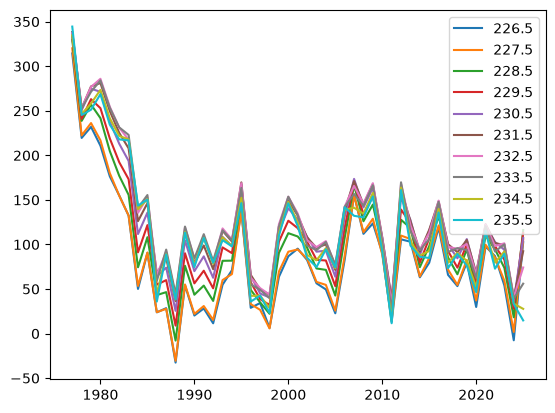

In [95]:
###
# Analysis on Mode 1 #
###
a1 = a_all.sel(mode=1)

for j_val in a1.j.values[0:10]:
    # print(j_val)
    plt.plot(Psi.time_counter.values, a1.sel(j=j_val), label=f"{j_val}")
    plt.legend()

plt.show()

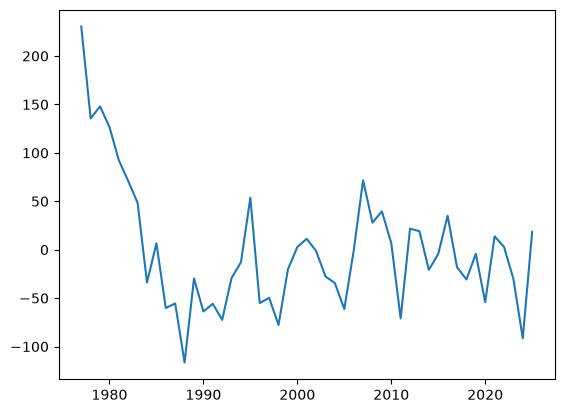

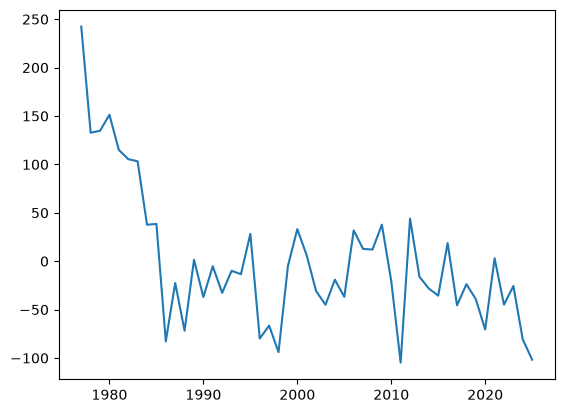

In [94]:
###
# fitting GP across Mode 1 for all latitudes #
###
a1 = a_prime_all.sel(mode=1)


plt.plot(Psi.time_counter.values, a1.sel(j=a1.j.values[0]), label=f"{j_val}")
plt.show()
plt.plot(Psi.time_counter.values, a1.sel(j=a1.j.values[10]))
plt.show()


MODE 1
Number of latitudes: 30
Number of time samples: 49
Raw matrix shape: (30, 49)
Perturbation matrix shape: (30, 49)


MODE 1 — raw coefficients


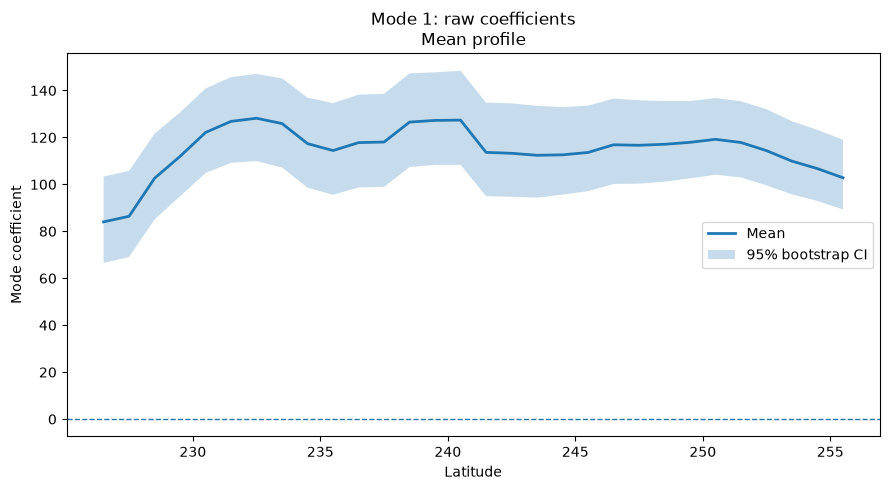

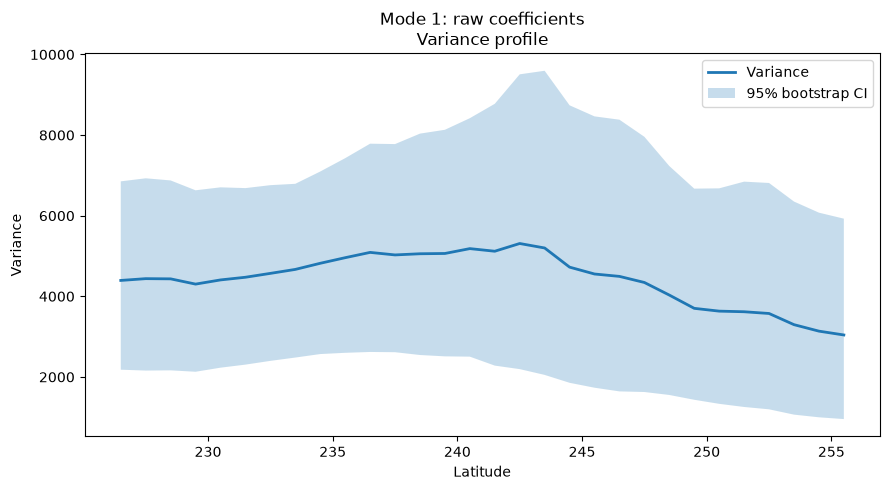

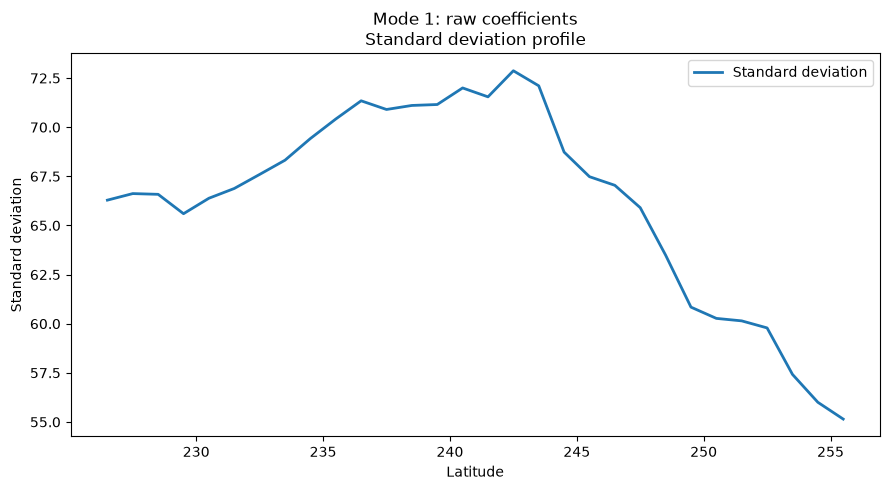


Brown–Forsythe test
--------------------
Statistic: 0.5666477952383896
p-value: 0.9694881587668412
Interpretation: no significant evidence of variance heterogeneity across latitude.

Variance range:
minimum: 3041.1200269403034
maximum: 5310.453324941917

Standard-deviation range:
minimum: 55.14635098481407
maximum: 72.87285725797993

Mean range:
minimum: 84.00852775892285
maximum: 128.16597678655225


MODE 1 — time-demeaned coefficients


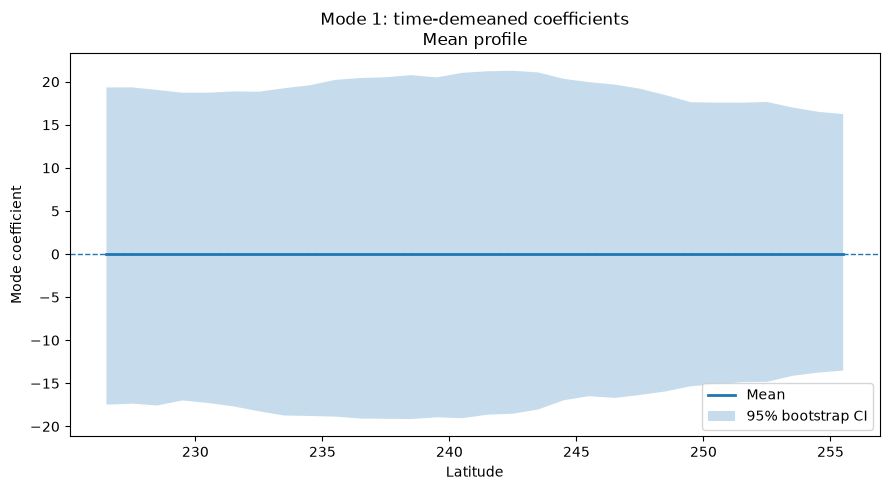

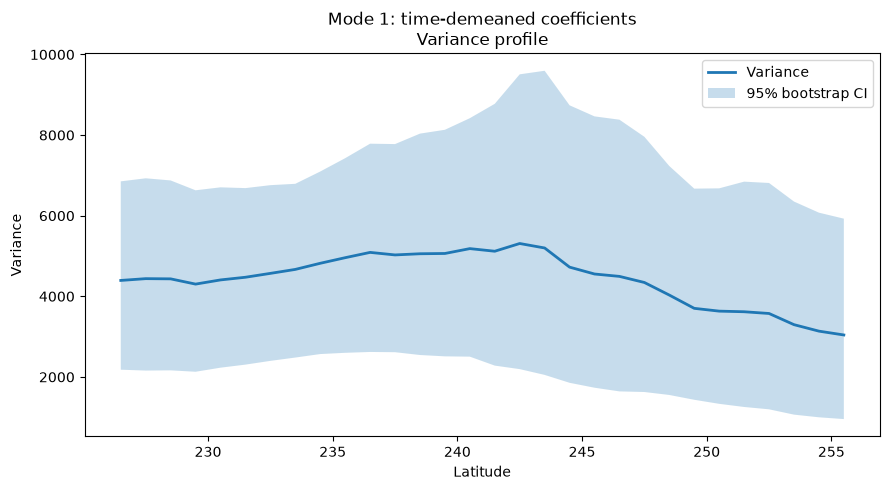

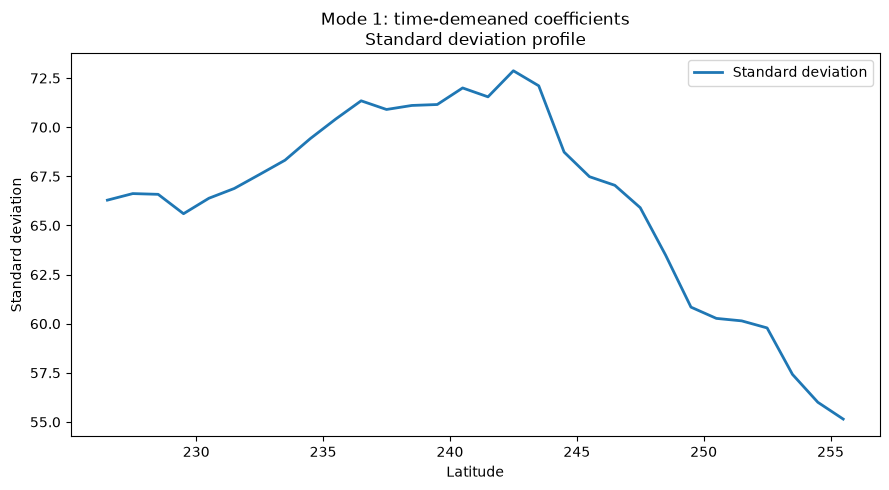


Brown–Forsythe test
--------------------
Statistic: 0.5666477952383897
p-value: 0.9694881587668412
Interpretation: no significant evidence of variance heterogeneity across latitude.

Variance range:
minimum: 3041.120026940305
maximum: 5310.453324941917

Standard-deviation range:
minimum: 55.14635098481408
maximum: 72.87285725797993

Mean range:
minimum: -2.784167454406923e-14
maximum: 1.5425302758465442e-14


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import levene


# ============================================================
# SETTINGS
# ============================================================

mode_n = 1

n_boot = 2000
ci = 95

rng_seed = 42


# ============================================================
# EXTRACT ONE MODE
# ============================================================

# ------------------------------------------------------------
# RAW / FULL coefficients
# Mean is retained
# ------------------------------------------------------------

A_raw = a_all.sel(mode=mode_n).transpose(
    "j",
    "time_counter"
)

# ------------------------------------------------------------
# PERTURBATION coefficients
# Temporal mean has been removed
# ------------------------------------------------------------

A_prime = a_prime_all.sel(mode=mode_n).transpose(
    "j",
    "time_counter"
)

lat = A_raw.j.values

X_raw = A_raw.values
X_prime = A_prime.values

L, T = X_raw.shape

print("=" * 70)
print(f"MODE {mode_n}")
print("=" * 70)

print("Number of latitudes:", L)
print("Number of time samples:", T)
print("Raw matrix shape:", X_raw.shape)
print("Perturbation matrix shape:", X_prime.shape)


# ============================================================
# BOOTSTRAP FUNCTION
# ============================================================

def bootstrap_statistics(
    X,
    n_boot=2000,
    ci=95,
    seed=42,
):

    rng = np.random.default_rng(seed)

    L, T = X.shape

    # --------------------------------------------------------
    # Observed statistics
    # --------------------------------------------------------

    mean_hat = np.mean(X, axis=1)

    variance_hat = np.var(
        X,
        axis=1,
        ddof=1,
    )

    std_hat = np.sqrt(variance_hat)

    # --------------------------------------------------------
    # Bootstrap distributions
    # --------------------------------------------------------

    boot_mean = np.empty((n_boot, L))
    boot_variance = np.empty((n_boot, L))

    for b in range(n_boot):

        # Resample TIME indices.
        #
        # Each bootstrap sample contains T time samples,
        # sampled with replacement.
        #
        # The same time indices are used for all latitudes
        # so that the spatial/latitudinal structure of each
        # realisation is preserved.
        idx = rng.integers(
            0,
            T,
            size=T,
        )

        Xb = X[:, idx]

        boot_mean[b, :] = np.mean(
            Xb,
            axis=1,
        )

        boot_variance[b, :] = np.var(
            Xb,
            axis=1,
            ddof=1,
        )

    # --------------------------------------------------------
    # Confidence limits
    # --------------------------------------------------------

    alpha = (100 - ci) / 2

    mean_low = np.percentile(
        boot_mean,
        alpha,
        axis=0,
    )

    mean_high = np.percentile(
        boot_mean,
        100 - alpha,
        axis=0,
    )

    variance_low = np.percentile(
        boot_variance,
        alpha,
        axis=0,
    )

    variance_high = np.percentile(
        boot_variance,
        100 - alpha,
        axis=0,
    )

    return {
        "mean": mean_hat,
        "mean_low": mean_low,
        "mean_high": mean_high,

        "variance": variance_hat,
        "variance_low": variance_low,
        "variance_high": variance_high,

        "std": std_hat,
    }


# ============================================================
# DIAGNOSTIC FUNCTION
# ============================================================

def run_diagnostics(
    X,
    lat,
    label,
    mode_n,
    n_boot=2000,
    ci=95,
    seed=42,
):

    print("\n")
    print("=" * 70)
    print(f"MODE {mode_n} — {label}")
    print("=" * 70)

    results = bootstrap_statistics(
        X,
        n_boot=n_boot,
        ci=ci,
        seed=seed,
    )

    mean_hat = results["mean"]
    mean_low = results["mean_low"]
    mean_high = results["mean_high"]

    variance_hat = results["variance"]
    variance_low = results["variance_low"]
    variance_high = results["variance_high"]

    std_hat = results["std"]


    # ========================================================
    # 1. MEAN PROFILE
    # ========================================================

    plt.figure(figsize=(9, 5))

    plt.plot(
        lat,
        mean_hat,
        linewidth=2,
        label="Mean",
    )

    plt.fill_between(
        lat,
        mean_low,
        mean_high,
        alpha=0.25,
        label="95% bootstrap CI",
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1,
    )

    plt.xlabel("Latitude")
    plt.ylabel("Mode coefficient")
    plt.title(
        f"Mode {mode_n}: {label}\n"
        "Mean profile"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


    # ========================================================
    # 2. VARIANCE PROFILE
    # ========================================================

    plt.figure(figsize=(9, 5))

    plt.plot(
        lat,
        variance_hat,
        linewidth=2,
        label="Variance",
    )

    plt.fill_between(
        lat,
        variance_low,
        variance_high,
        alpha=0.25,
        label="95% bootstrap CI",
    )

    plt.xlabel("Latitude")
    plt.ylabel("Variance")
    plt.title(
        f"Mode {mode_n}: {label}\n"
        "Variance profile"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


    # ========================================================
    # 3. STANDARD DEVIATION PROFILE
    #
    # This is useful because:
    #
    # variance = standard deviation^2
    #
    # If variance = 60,
    # standard deviation = sqrt(60) = 7.75.
    # ========================================================

    plt.figure(figsize=(9, 5))

    plt.plot(
        lat,
        std_hat,
        linewidth=2,
        label="Standard deviation",
    )

    plt.xlabel("Latitude")
    plt.ylabel("Standard deviation")
    plt.title(
        f"Mode {mode_n}: {label}\n"
        "Standard deviation profile"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


    # ========================================================
    # 4. BROWN–FORSYTHE TEST
    # ========================================================

    groups = [
        X[i, :]
        for i in range(X.shape[0])
    ]

    statistic, p_value = levene(
        *groups,
        center="median",
    )

    print("\nBrown–Forsythe test")
    print("--------------------")

    print("Statistic:", statistic)
    print("p-value:", p_value)

    if p_value < 0.05:

        print(
            "Interpretation: significant evidence "
            "of variance heterogeneity across latitude."
        )

    else:

        print(
            "Interpretation: no significant evidence "
            "of variance heterogeneity across latitude."
        )


    # ========================================================
    # 5. SUMMARY NUMBERS
    # ========================================================

    print("\nVariance range:")
    print(
        "minimum:",
        np.min(variance_hat)
    )
    print(
        "maximum:",
        np.max(variance_hat)
    )

    print("\nStandard-deviation range:")
    print(
        "minimum:",
        np.min(std_hat)
    )
    print(
        "maximum:",
        np.max(std_hat)
    )

    print("\nMean range:")
    print(
        "minimum:",
        np.min(mean_hat)
    )
    print(
        "maximum:",
        np.max(mean_hat)
    )


    return results


# ============================================================
# RAW COEFFICIENTS
#
# IMPORTANT:
# This uses a_all, NOT a_prime_all.
# Therefore the temporal mean is retained.
# ============================================================

raw_results = run_diagnostics(
    X_raw,
    lat,
    label="raw coefficients",
    mode_n=mode_n,
    n_boot=n_boot,
    ci=ci,
    seed=rng_seed,
)


# ============================================================
# PERTURBATION COEFFICIENTS
#
# This uses a_prime_all.
# Its temporal mean should be approximately zero.
# ============================================================

prime_results = run_diagnostics(
    X_prime,
    lat,
    label="time-demeaned coefficients",
    mode_n=mode_n,
    n_boot=n_boot,
    ci=ci,
    seed=rng_seed,
)